In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## About Dataset

This dataset contains **12,009 patient records (rows)** collected from a hospital laboratory.

It includes demographic information such as **Age** and **Gender**, along with various medical test parameters:

- RBC (Red Blood Cell Count)
- WBC (White Blood Cell Count)
- Hemoglobin
- AST (Aspartate Aminotransferase)
- ALT (Alanine Aminotransferase)
- Cholesterol
- Glucose
- Lipase
- Spirometry
- Creatinine
- Troponin

The dataset can be used to analyze the relationship between medical test results and different diseases. By studying variations in these parameters, it is possible to identify patterns and understand how abnormal test values may be associated with specific health conditions.

In [2]:
df = pd.read_csv('laboratory__data.csv')
df.head()

,Gender,Age,Hemoglobin,RBC,WBC,AST (aspartate aminotransferase),ALT (alanine aminotransferase),Cholestrol,Spirometry,Creatinine,Glucose,Lipase,Troponin,Disease
0,Male,59,6,1.20,6220,26,22,227,4.75,0.90,96,97,0.02,Anemia
1,Male,71,40,20.00,6636,18,27,220,3.93,1.03,94,82,0.04,Asthma
2,Female,22,14,3.55,18314,21,30,224,3.93,1.17,70,101,0.00,Infection
3,Male,53,16,4.95,9931,45,62,205,3.58,0.81,82,108,0.03,Liver Disease
4,Male,77,16,3.96,7088,29,25,217,3.20,1.70,97,107,0.04,Liver Disease


In [3]:
df.shape

(12009, 14)

In [4]:
df.columns

Index(['Gender', 'Age', 'Hemoglobin', 'RBC', 'WBC',
       'AST (aspartate aminotransferase)', 'ALT (alanine aminotransferase)',
       'Cholestrol', 'Spirometry', 'Creatinine', 'Glucose', 'Lipase',
       'Troponin', 'Disease '],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12009 entries, 0 to 12008
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            12009 non-null  object 
 1   Age                               12009 non-null  int64  
 2   Hemoglobin                        12009 non-null  int64  
 3   RBC                               12009 non-null  float64
 4   WBC                               12009 non-null  int64  
 5   AST (aspartate aminotransferase)  12009 non-null  int64  
 6   ALT (alanine aminotransferase)    12009 non-null  int64  
 7   Cholestrol                        12009 non-null  int64  
 8   Spirometry                        12009 non-null  float64
 9   Creatinine                        12009 non-null  float64
 10  Glucose                           12009 non-null  int64  
 11  Lipase                            12009 non-null  int64  
 12  Trop

In [6]:
df.describe()

,Age,Hemoglobin,RBC,WBC,AST (aspartate aminotransferase),ALT (alanine aminotransferase),Cholestrol,Spirometry,Creatinine,Glucose,Lipase,Troponin
count,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000,12009.000000
mean,54.415438,11.988342,3.421939,9154.022317,24.613457,31.168873,217.975685,3.798141,1.099124,90.801815,101.816554,0.027720
std,21.160408,4.681409,1.925999,3922.574987,8.150145,11.565622,13.956727,0.887210,0.295349,18.361879,27.901340,0.023478
min,18.000000,2.000000,0.110000,6005.000000,15.000000,20.000000,200.000000,1.010000,0.800000,70.000000,70.000000,0.000000
25%,36.000000,6.000000,1.120000,7061.000000,19.000000,24.000000,208.000000,3.390000,0.910000,78.000000,83.000000,0.010000
50%,55.000000,14.000000,4.000000,8187.000000,23.000000,28.000000,216.000000,3.940000,1.030000,87.000000,97.000000,0.020000
75%,73.000000,15.000000,4.530000,9207.000000,28.000000,33.000000,224.000000,4.440000,1.140000,96.000000,110.000000,0.030000
max,90.000000,50.000000,34.000000,27901.000000,50.000000,70.000000,281.000000,5.010000,2.000000,157.000000,202.000000,0.100000


In [7]:
# checking for missing values
df.isnull().sum()
print("Total missing values in the dataset:", df.isnull().sum().sum())
# checking for duplicates
df.duplicated().sum()
print("Total duplicate rows in the dataset:", df.duplicated().sum())

Total missing values in the dataset: 0
Total duplicate rows in the dataset: 0


In [8]:
# remove extra spaces from columns names 
df.columns = df.columns.str.strip()
print("Columns after stripping spaces:", df.columns)

Columns after stripping spaces: Index(['Gender', 'Age', 'Hemoglobin', 'RBC', 'WBC',
       'AST (aspartate aminotransferase)', 'ALT (alanine aminotransferase)',
       'Cholestrol', 'Spirometry', 'Creatinine', 'Glucose', 'Lipase',
       'Troponin', 'Disease'],
      dtype='object')


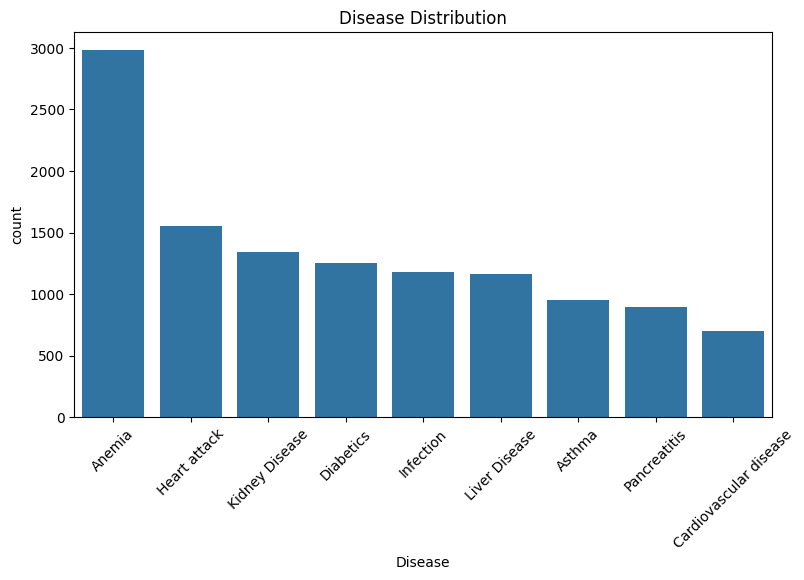

In [9]:
# check the distribution of the target variable
plt.figure(figsize=(9,5))
sns.countplot(x='Disease', data=df, order=df['Disease'].value_counts().index)
plt.title('Disease Distribution')
plt.xticks(rotation=45)
plt.show()


In [10]:
df['Disease'].unique()

array(['Anemia', 'Asthma', 'Infection', 'Liver Disease',
       'Cardiovascular disease', 'Diabetics', 'Kidney Disease',
       'Heart attack', 'Pancreatitis'], dtype=object)

In [11]:
# value counts of the target variable
df['Disease'].value_counts()

Disease
Anemia                    2979
Heart attack              1555
Kidney Disease            1341
Diabetics                 1251
Infection                 1176
Liver Disease             1162
Asthma                     955
Pancreatitis               893
Cardiovascular disease     697
Name: count, dtype: int64

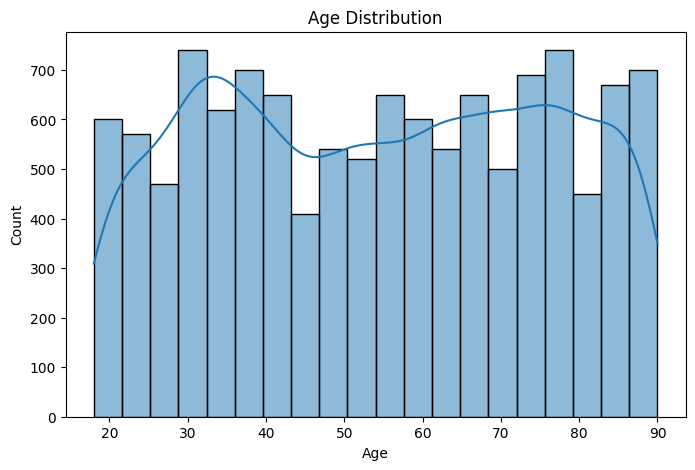

In [12]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

#### The age distribution is spread across different age groups and appears fairly balanced. Small peaks are visible around 30–40 and 70–80 years, but overall no major imbalance or unusual pattern is observed.

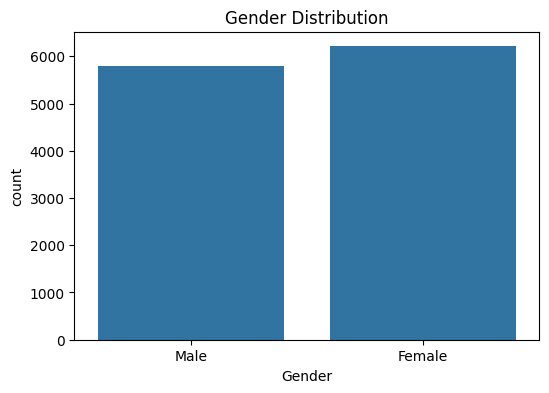

In [13]:
# gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

### Age Distribution Interpretation

- X-axis shows Age values and Y-axis shows Count  
- Age values range approximately from 18 to 90 years  
- More samples can be seen around 30–40 years and 70–80 years  
- Different age groups are present in the dataset  
- No single age group contains all samples  

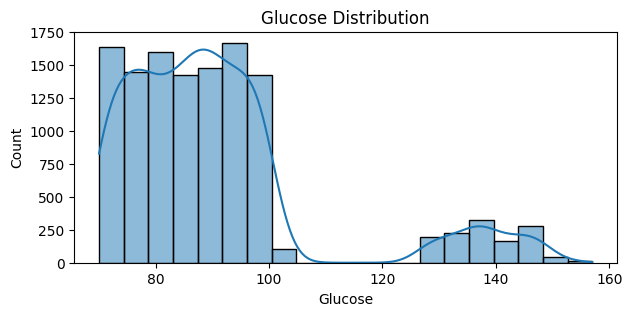

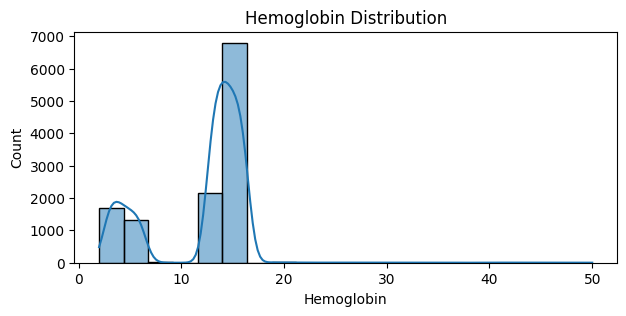

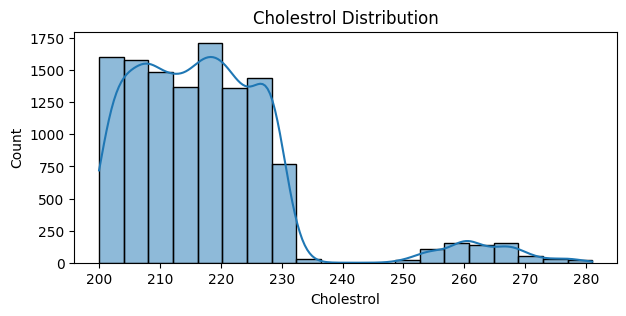

In [14]:
# blood parameter distribution
features = ['Glucose', 'Hemoglobin', 'Cholestrol']

for col in features:
    plt.figure(figsize=(7,3))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

### Glucose Distribution Interpretation

- X-axis shows Glucose values and Y-axis shows Count  
- Two peaks can be seen in the graph  
- One peak appears around 80–100 glucose values  
- Another smaller peak appears around 135–145 glucose values  
- Glucose values are spread across multiple ranges  

### Hemoglobin Distribution Interpretation

- X-axis shows Hemoglobin values and Y-axis shows Count  
- Two peaks can be seen in the graph  
- Most samples appear around 13–16 hemoglobin values  
- Another smaller group appears around 5–7 hemoglobin values  
- Hemoglobin values vary across different ranges  


### Cholesterol Distribution Interpretation

- X-axis shows Cholesterol values and Y-axis shows Count  
- Most samples appear around 200–225 cholesterol values  
- Higher cholesterol values around 230–280 appear less frequently  
- Cholesterol values are spread across different ranges  
- The graph extends more toward higher cholesterol values  

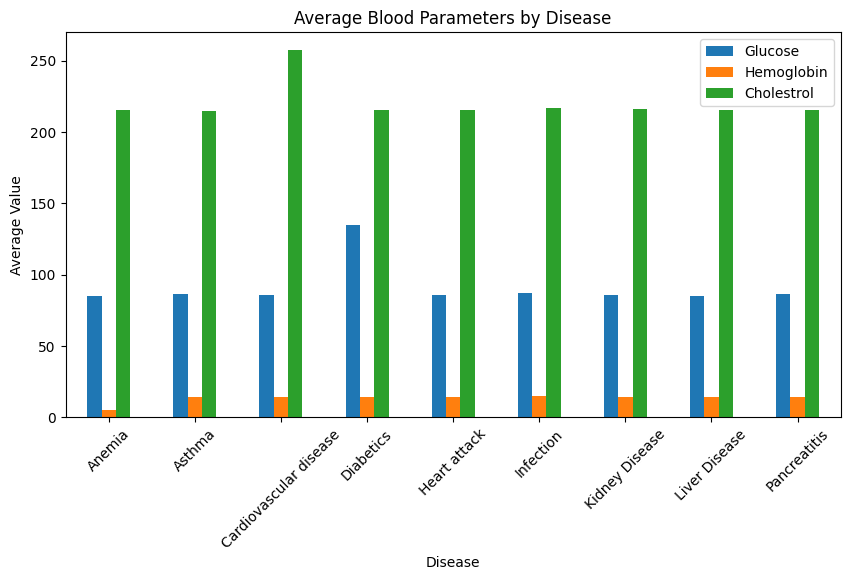

In [15]:
# average features values by disease
disease_avg = df.groupby('Disease')[
    ['Glucose','Hemoglobin','Cholestrol']
].mean()

disease_avg.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Blood Parameters by Disease')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()

### Disease-wise Average Blood Parameters Interpretation

- X-axis shows different disease categories  
- Y-axis shows average values of blood parameters  
- Blue bars represent Glucose values  
- Orange bars represent Hemoglobin values  
- Green bars represent Cholesterol values  

- Different diseases show different patterns of blood parameters  
- Diabetes shows higher average glucose compared to many other diseases  
- Anemia shows lower average hemoglobin values  
- Cholesterol values are relatively higher for some disease categories  
- Some diseases have similar patterns while others show clear differences  
- The variation between bars suggests blood parameters change across diseases  

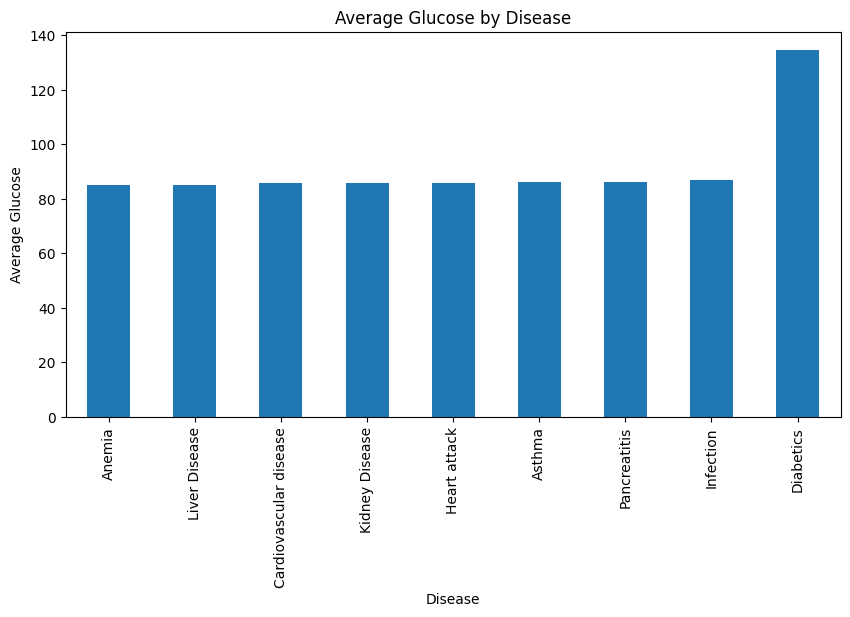

In [16]:
avg_glucose = df.groupby('Disease')['Glucose'].mean()

avg_glucose.sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Glucose by Disease')
plt.ylabel('Average Glucose')
plt.show()

### Average Glucose by Disease Interpretation

- X-axis shows disease categories  
- Y-axis shows average glucose values  
- Diabetes has higher average glucose compared to other diseases  
- Most other diseases have similar glucose ranges  
- The graph shows glucose values vary across diseases  

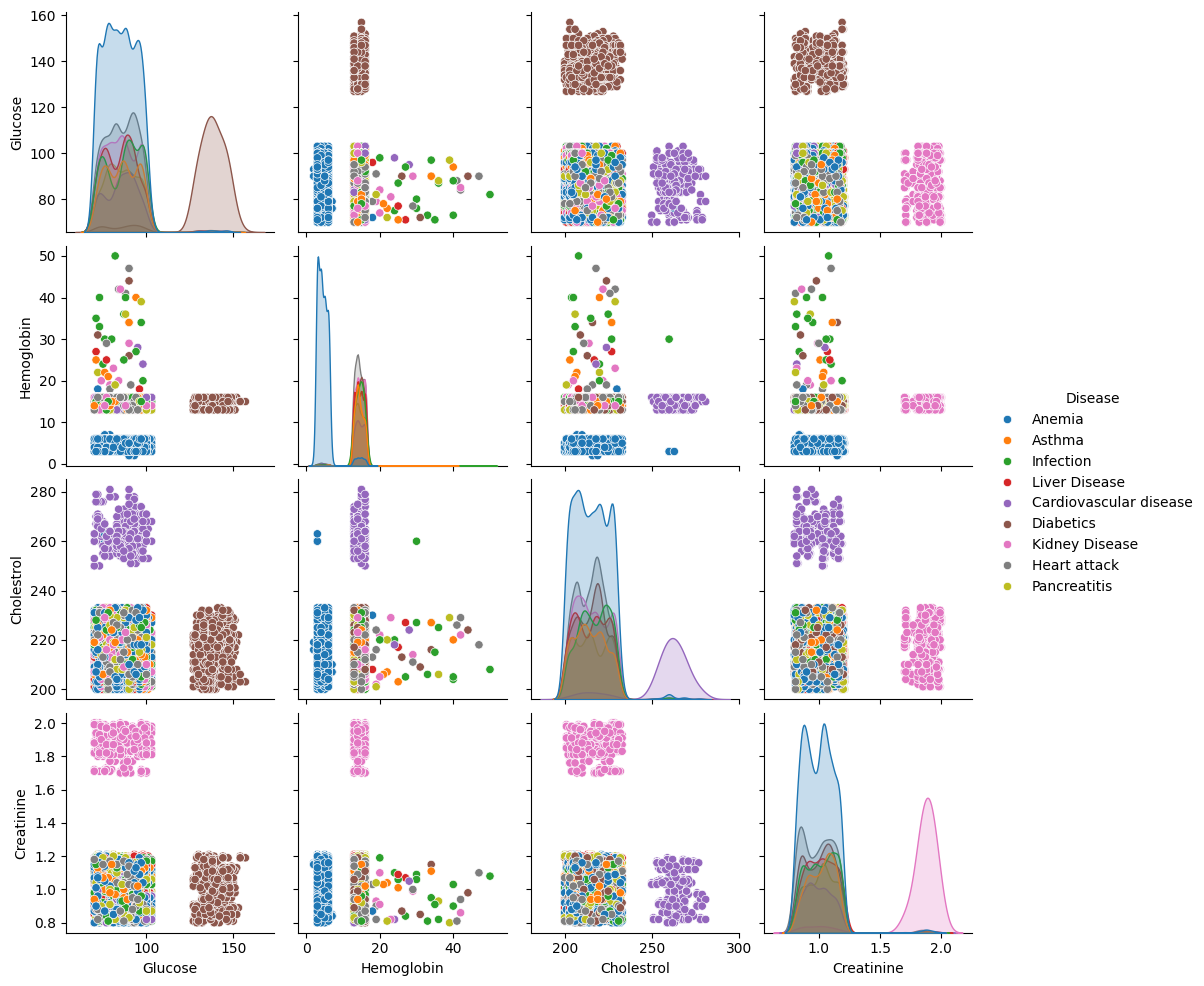

<Figure size 1500x600 with 0 Axes>

In [17]:
# pairplot to see relationships between features 
selected_cols = [
    'Glucose',
    'Hemoglobin',
    'Cholestrol',
    'Creatinine',
    'Disease'
]

sns.pairplot(
    df[selected_cols],
    hue='Disease'
)
plt.xticks(rotation=45)
plt.figure(figsize=(15,6))
plt.show()

### Pair Plot Interpretation

- Pair plot shows both feature distributions and relationships between features  
- Diagonal graphs show how values are distributed for each feature  
- Glucose values are mostly present between 80–140 range  
- Hemoglobin values are mostly between 5–16 range  
- Cholesterol values are spread approximately from 180–280 range  
- Creatinine values mostly appear in lower ranges with some higher values present  
- Some disease categories appear grouped separately while some overlap  
- Overall, the plot helps compare multiple features together across diseases  

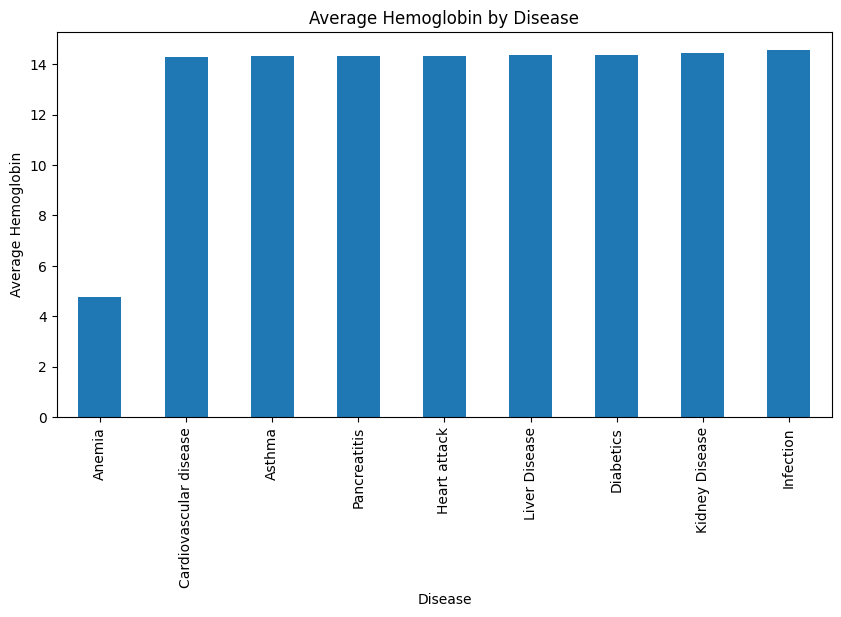

In [18]:
avg_hemo = df.groupby('Disease')['Hemoglobin'].mean()

avg_hemo.sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Hemoglobin by Disease')
plt.ylabel('Average Hemoglobin')
plt.show()

### Average Hemoglobin by Disease Interpretation

- X-axis shows disease categories  
- Y-axis shows average hemoglobin values  
- Anemia shows lower average hemoglobin values compared to other diseases  
- Most other diseases have hemoglobin values in a similar range  
- A clear difference can be seen between Anemia and other disease categories  
- The graph shows different hemoglobin levels for different diseases  

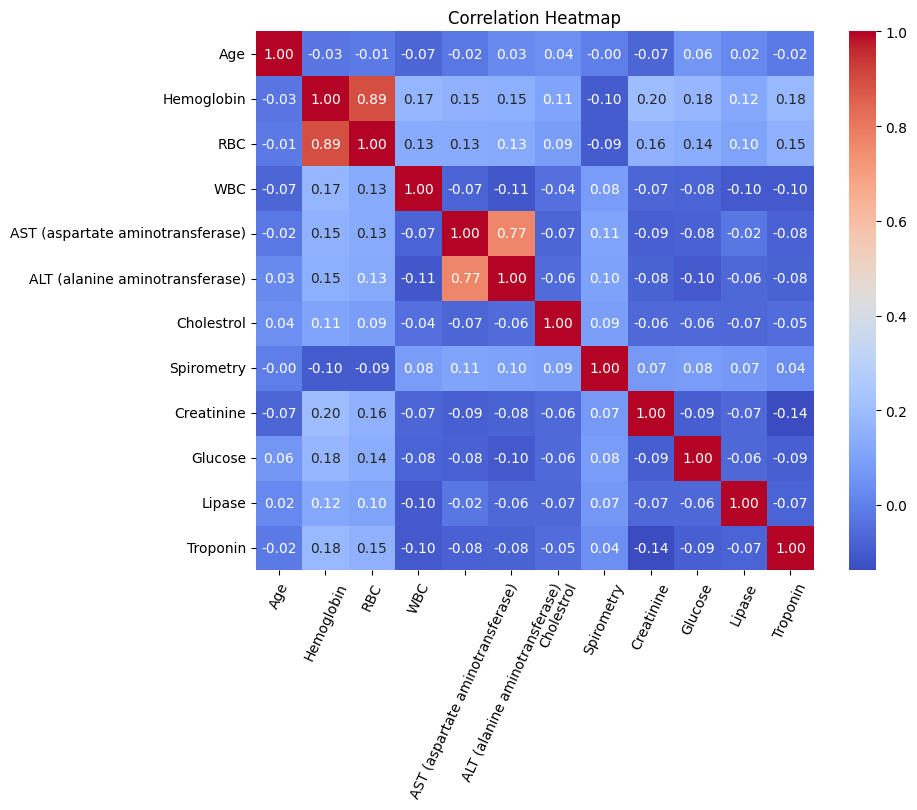

In [19]:
# correlation heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.xticks(rotation=65)
plt.show()

### Correlation Heatmap Interpretation

- Heatmap shows how features are related to each other  
- Dark colors show stronger relationships, while lighter colors show weaker relationships  
- Most features have low correlation with each other  
- Some feature pairs show higher correlation than others  
- Features with higher correlation tend to change together  
- The heatmap helps understand connections between different features  

In [ ]:
# male - 0 , female - 1
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
print(df['Gender'].value_counts())      



Gender
1    6209
0    5800
Name: count, dtype: int64


In [21]:
# Encode target variable using LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Disease'] = le.fit_transform(df['Disease'])

print(dict(zip(le.transform(le.classes_), le.classes_)))

{np.int64(0): 'Anemia', np.int64(1): 'Asthma', np.int64(2): 'Cardiovascular disease', np.int64(3): 'Diabetics', np.int64(4): 'Heart attack', np.int64(5): 'Infection', np.int64(6): 'Kidney Disease', np.int64(7): 'Liver Disease', np.int64(8): 'Pancreatitis'}


| Encoded Value | Disease                |
| ------------- | ---------------------- |
| 0             | Anemia                 |
| 1             | Asthma                 |
| 2             | Cardiovascular disease |
| 3             | Diabetics              |
| 4             | Heart attack           |
| 5             | Infection              |
| 6             | Kidney Disease         |
| 7             | Liver Disease          |
| 8             | Pancreatitis           |


In [22]:
# set features and target variable
X = df.drop(columns=['Disease'])
y = df['Disease']


In [23]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (9607, 13)
Test set shape: (2402, 13)


In [24]:
X_test

,Gender,Age,Hemoglobin,RBC,WBC,AST (aspartate aminotransferase),ALT (alanine aminotransferase),Cholestrol,Spirometry,Creatinine,Glucose,Lipase,Troponin
1689,1,40,14,3.79,9137,15,21,267,4.85,0.82,71,82,0.03
7221,1,47,13,4.71,6098,43,62,227,4.36,0.88,75,73,0.00
5953,1,73,16,5.05,8987,26,25,228,3.10,0.90,94,80,0.08
291,0,36,3,0.61,7668,27,28,200,3.52,1.20,81,108,0.01
1040,1,75,15,4.29,8499,16,27,224,4.95,1.09,95,185,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,0,89,16,4.78,8430,24,23,220,4.33,1.12,145,91,0.03
10654,1,81,16,4.33,8294,30,34,213,3.19,1.12,147,91,0.01
784,0,73,16,3.91,9062,18,24,254,4.22,1.15,85,86,0.04
3877,0,87,16,4.46,8077,18,34,227,4.96,2.00,97,103,0.02


In [25]:
# scaling features
# scaling features - using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    

In [26]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred_log_reg = model.predict(X_test_scaled)

print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))
print("Accuracy Score:", accuracy_score(y_test, y_pred_log_reg))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.95      0.96      0.96       191
           2       0.95      0.89      0.92       139
           3       0.92      0.94      0.93       250
           4       0.93      0.95      0.94       311
           5       0.94      0.93      0.93       235
           6       0.95      0.87      0.91       268
           7       0.94      0.94      0.94       233
           8       0.93      0.96      0.94       179

    accuracy                           0.94      2402
   macro avg       0.94      0.93      0.94      2402
weighted avg       0.94      0.94      0.94      2402

Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   1   1   2   1   0]
 [  2   1 124   4   5   1   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   2   2   1   4]
 [  5   1   0   3   3 218   2   2   1]
 [  7   4   5   3 

In [27]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("KNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))


KNN Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.94      0.96      0.95       191
           2       0.95      0.91      0.93       139
           3       0.93      0.94      0.93       250
           4       0.95      0.95      0.95       311
           5       0.93      0.94      0.93       235
           6       0.95      0.87      0.91       268
           7       0.95      0.94      0.95       233
           8       0.94      0.96      0.95       179

    accuracy                           0.94      2402
   macro avg       0.94      0.94      0.94      2402
weighted avg       0.94      0.94      0.94      2402

KNN Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   0   2   2   1   0]
 [  2   1 127   3   2   2   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   3   2   1   3]
 [  5   1   0   3   3 220   2   0   1]
 [  7   5 

In [28]:
# SVM Classifier
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svm))


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.95      0.96      0.96       191
           2       0.95      0.91      0.93       139
           3       0.93      0.94      0.94       250
           4       0.94      0.95      0.94       311
           5       0.92      0.93      0.93       235
           6       0.95      0.87      0.91       268
           7       0.94      0.94      0.94       233
           8       0.94      0.96      0.95       179

    accuracy                           0.94      2402
   macro avg       0.94      0.94      0.94      2402
weighted avg       0.94      0.94      0.94      2402

SVM Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   0   2   2   1   0]
 [  2   1 127   2   2   3   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   3   2   1   3]
 [  5   1   0   3   3 218   2   2   1]
 [  7   4 

In [29]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Accuracy Score:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82       596
           1       0.75      0.79      0.77       191
           2       0.62      0.71      0.66       139
           3       0.73      0.71      0.72       250
           4       0.66      0.73      0.69       311
           5       0.74      0.69      0.71       235
           6       0.76      0.68      0.72       268
           7       0.79      0.84      0.81       233
           8       0.78      0.82      0.80       179

    accuracy                           0.76      2402
   macro avg       0.74      0.75      0.74      2402
weighted avg       0.76      0.76      0.76      2402

Decision Tree Confusion Matrix:
 [[477  11  14  15  29  19  13  12   6]
 [  4 150  14   5   3   6   3   4   2]
 [  5   2  98   5  12   9   3   4   1]
 [ 17   9   1 178  19   5   5  12   4]
 [ 24   5  11  13 226   6  14   4   8]
 [  8   6   1  10  19 162  12

In [30]:
# XGBoost Classifier
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)

print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred_xgb))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.95      0.96      0.95       191
           2       0.95      0.91      0.93       139
           3       0.93      0.94      0.93       250
           4       0.94      0.95      0.94       311
           5       0.94      0.94      0.94       235
           6       0.95      0.87      0.91       268
           7       0.95      0.94      0.95       233
           8       0.94      0.96      0.95       179

    accuracy                           0.94      2402
   macro avg       0.94      0.94      0.94      2402
weighted avg       0.94      0.94      0.94      2402

XGBoost Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   1   1   2   1   0]
 [  3   1 126   3   2   2   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   3   2   1   3]
 [  5   1   0   3   3 220   2   0   1]
 [

In [31]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.95      0.96      0.96       191
           2       0.95      0.91      0.93       139
           3       0.93      0.94      0.94       250
           4       0.95      0.95      0.95       311
           5       0.92      0.94      0.93       235
           6       0.95      0.87      0.91       268
           7       0.95      0.94      0.95       233
           8       0.94      0.96      0.95       179

    accuracy                           0.94      2402
   macro avg       0.94      0.94      0.94      2402
weighted avg       0.94      0.94      0.94      2402

Random Forest Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   0   2   2   1   0]
 [  2   1 127   2   2   3   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   3   2   1   3]
 [  5   1   0   3   3 220   2

In [32]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9365046320391381
Test Accuracy : 0.9425478767693589


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.70108243 0.98334721 1.         1.         1.        ]
Mean CV Accuracy: 0.9368859283930059


In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                             Feature  Importance
2                         Hemoglobin    0.127788
12                          Troponin    0.126536
3                                RBC    0.121545
9                         Creatinine    0.118914
10                           Glucose    0.103199
4                                WBC    0.088281
8                         Spirometry    0.075484
5   AST (aspartate aminotransferase)    0.068894
11                            Lipase    0.063952
6     ALT (alanine aminotransferase)    0.054309
7                         Cholestrol    0.046443
1                                Age    0.004281
0                             Gender    0.000375


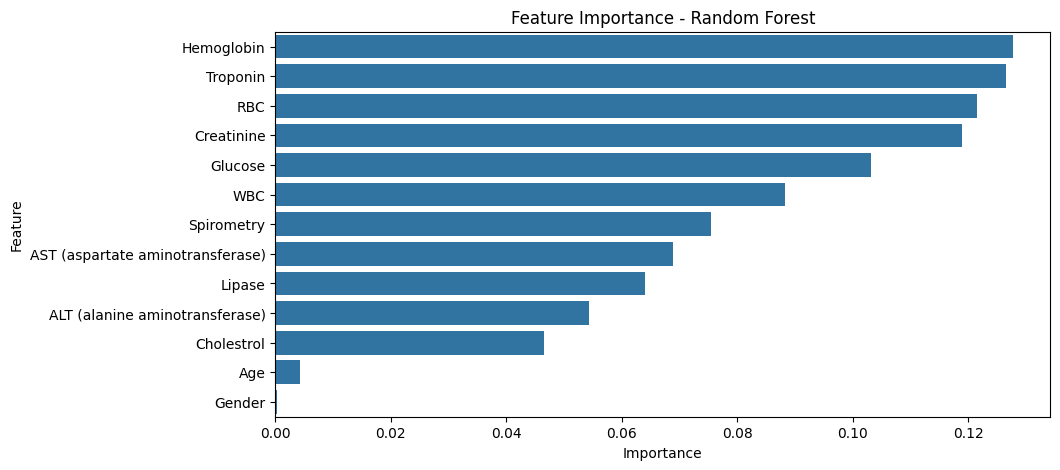

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.show()

In [36]:
#Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Naive Bayes Accuracy Score:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       596
           1       0.94      0.96      0.95       191
           2       0.95      0.89      0.92       139
           3       0.93      0.94      0.94       250
           4       0.95      0.95      0.95       311
           5       0.92      0.93      0.92       235
           6       0.95      0.87      0.91       268
           7       0.94      0.94      0.94       233
           8       0.94      0.96      0.95       179

    accuracy                           0.94      2402
   macro avg       0.94      0.93      0.94      2402
weighted avg       0.94      0.94      0.94      2402

Naive Bayes Confusion Matrix:
 [[580   1   1   1   5   1   1   4   2]
 [  2 183   0   1   0   2   2   1   0]
 [  2   4 124   2   2   3   0   1   1]
 [  7   0   1 235   1   2   2   2   0]
 [  3   1   0   3 295   3   2   1   3]
 [  5   1   0   3   3 218   2   2

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": y_pred_log_reg,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1 Score": f1_score(y_test, pred, average='weighted')
    })

results = pd.DataFrame(results)
results = results.sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
1                  KNN  0.942548   0.942665  0.942548  0.942328
5        Random Forest  0.942548   0.942695  0.942548  0.942343
6              XGBoost  0.942132   0.942263  0.942132  0.941906
2                  SVM  0.941715   0.941810  0.941715  0.941495
0  Logistic Regression  0.940466   0.940623  0.940466  0.940225
3          Naive Bayes  0.940466   0.940595  0.940466  0.940226
4        Decision Tree  0.755204   0.757883  0.755204  0.755662


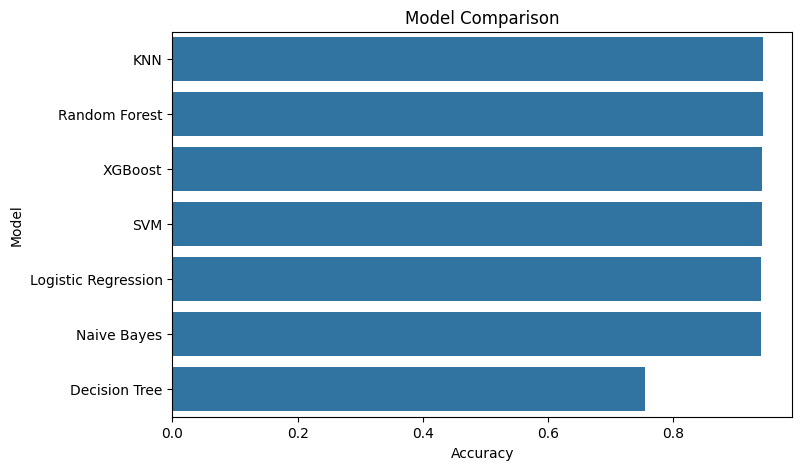

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results
)

plt.title("Model Comparison")
plt.show()

In [39]:
import joblib

joblib.dump(rf, "disease_prediction_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [40]:
model = joblib.load("disease_prediction_model.pkl")
le = joblib.load("label_encoder.pkl")

In [41]:
new_patient = pd.DataFrame(
    [[0,59,6,1.2,6220,26,22,227,4.75,0.9,96,97,0.02]],
    columns=X.columns
)

prediction = model.predict(new_patient)

print(
    "Predicted Disease:",
    le.inverse_transform(prediction)[0]
)

Predicted Disease: Anemia


In [42]:
# Predicting encoded label for new patient
new_patient = pd.DataFrame(
    [[0, 59, 6, 1.2, 6220, 26, 22, 227, 4.75, 0.9, 96, 97, 0.02]],
    columns=X.columns
)

prediction = rf.predict(new_patient)

print("Encoded Prediction:", prediction[0])

print("Predicted Disease:", le.inverse_transform(prediction)[0])

Encoded Prediction: 0
Predicted Disease: Anemia


In [43]:
disease_name = le.inverse_transform(prediction)

print("Predicted Disease:", disease_name[0])

Predicted Disease: Anemia


In [44]:
print(X.columns.tolist())
new_patient = [[
    0,      # Male = 0
    59,
    6,
    1.2,
    6220,
    26,
    22,
    227,
    4.75,
    0.9,
    96,
    97,
    0.02
]]
prediction = rf.predict(new_patient)

predicted_disease = le.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

['Gender', 'Age', 'Hemoglobin', 'RBC', 'WBC', 'AST (aspartate aminotransferase)', 'ALT (alanine aminotransferase)', 'Cholestrol', 'Spirometry', 'Creatinine', 'Glucose', 'Lipase', 'Troponin']
Predicted Disease: Anemia


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted:", le.inverse_transform(prediction)[0])
print("Actual   :", le.inverse_transform([y_test.iloc[0]])[0])

Predicted: Cardiovascular disease
Actual   : Cardiovascular disease


## Insights

- Different diseases show different patterns in blood parameters  
- Features such as Glucose, Hemoglobin, Cholesterol, and Creatinine show noticeable variation across diseases  
- Some features show clearer separation between disease categories while some features overlap  
- Correlation analysis shows most features have weak relationships with each other  
- Feature importance analysis shows that some medical parameters contribute more to prediction than others  
- Visualizations helped identify patterns, distributions, and relationships in the dataset  


## Conclusion

- EDA helped understand the structure and patterns present in the dataset  
- Multiple machine learning models were trained and compared for disease prediction  
- Random Forest showed strong performance compared to other models and was selected as the final model  
- The results show that laboratory parameters contain useful information for disease classification  
- Overall, machine learning can effectively learn patterns from medical data and perform disease prediction  